Error summary:


,classification_type,frequency_pct,model_missed_pct,raw_errors,avg_fraudulent_name_length,avg_real_name_length,avg_length_distance
0,punycode,0.081748,0.000000,0,21.177778,20.866667,0.533333
1,Non-ASCII,64.070703,0.724905,767,9.385003,9.110333,0.343304
2,unicode_homoglyph,18.174772,0.000000,0,9.183081,9.183081,0.000000
3,hyphen_change,6.330348,2.974938,311,10.652860,9.323991,1.351636
4,digit_change,6.029999,5.683872,566,9.877787,9.443061,0.525105
5,transposition,0.727863,0.998336,12,9.291181,9.291181,0.000000
6,insertion,39.675187,4.278083,2803,10.014698,8.965888,1.070055
7,deletion,11.762676,8.000000,1554,9.547851,9.600772,0.550013
8,substitution,82.267880,3.327739,4521,9.548271,9.212229,0.415890
9,digit_substitution,1.251052,5.856728,121,8.191191,8.191675,0.000484



Average string length buckets:


,avg_string_length_bucket_start,avg_string_length_bucket_end,avg_string_length_bucket_mean,accuracy_pct,frequency_pct
0,0.5,6.0,4.748798,90.719748,25.755393
1,6.0,7.5,7.005342,95.302114,15.520114
2,7.5,9.5,8.672913,97.263113,21.790210
3,9.5,12.0,10.884609,98.189342,20.037293
4,12.0,54.5,15.090241,98.990923,16.896989



Absolute length difference:


,abs_length_difference,accuracy_pct,frequency_pct
0,0,97.845261,56.571051
1,1,95.443255,33.886800
2,2,93.272479,8.424922
3,3,92.082430,1.116622
4,5,100.000000,0.000606


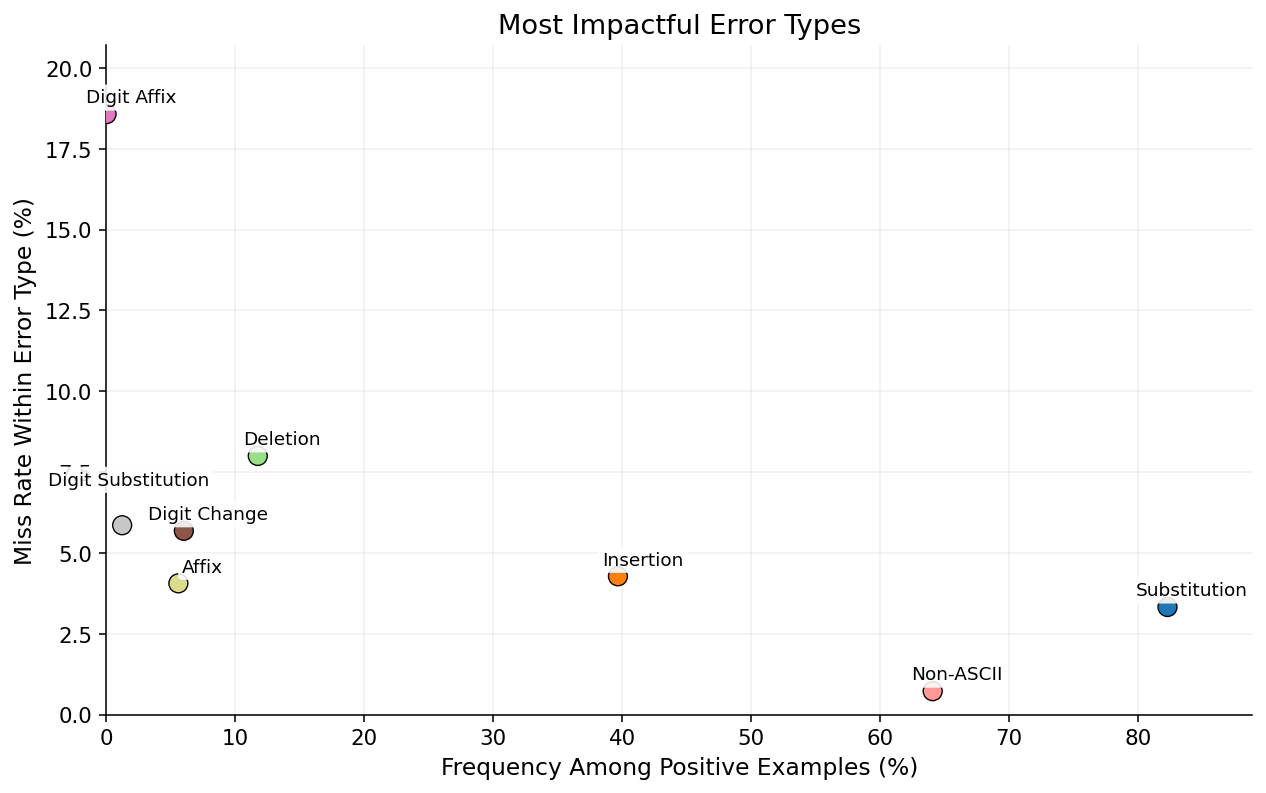

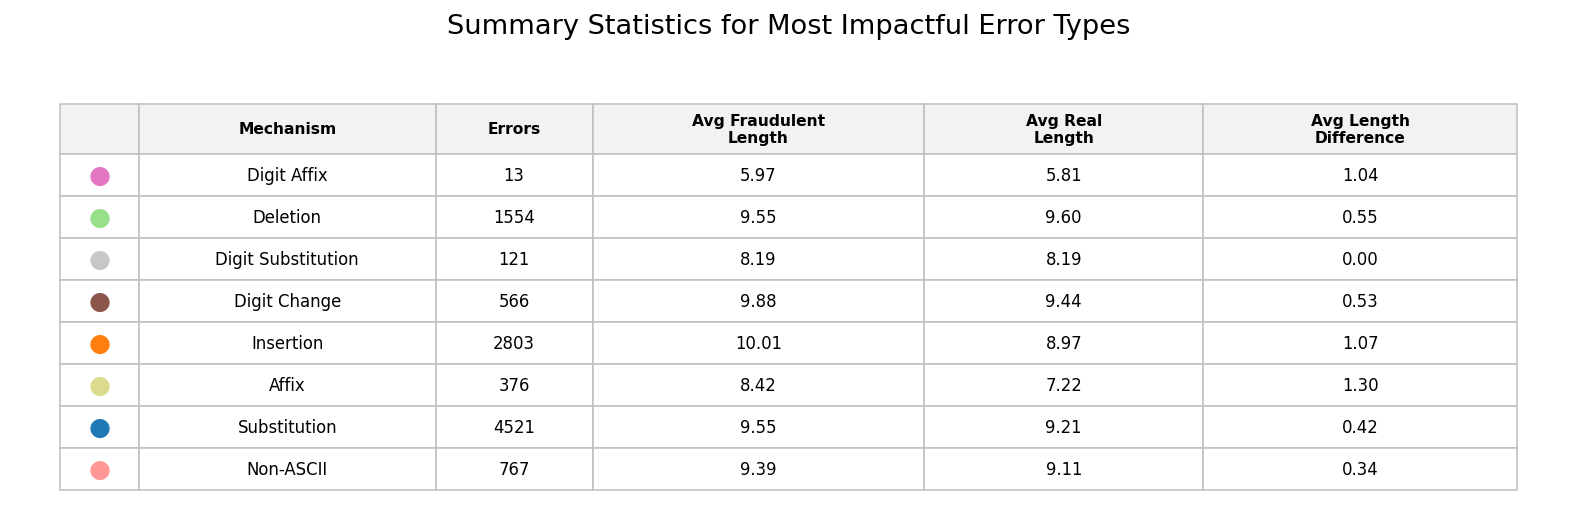

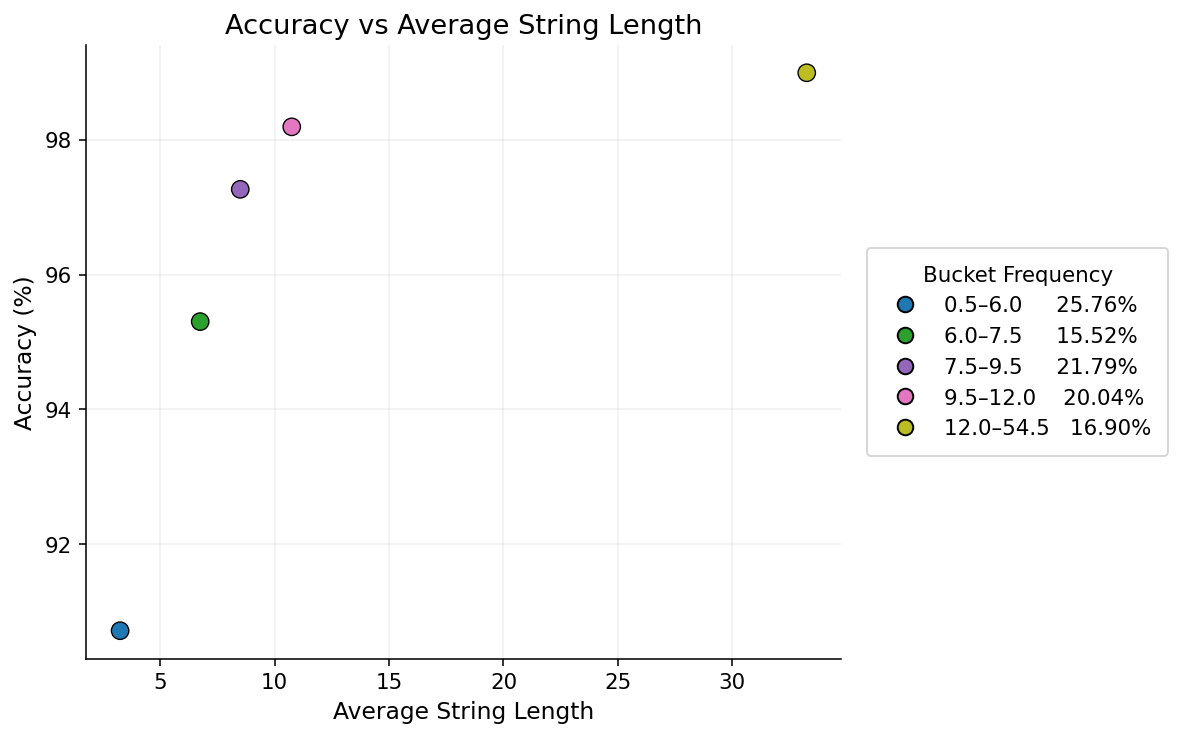

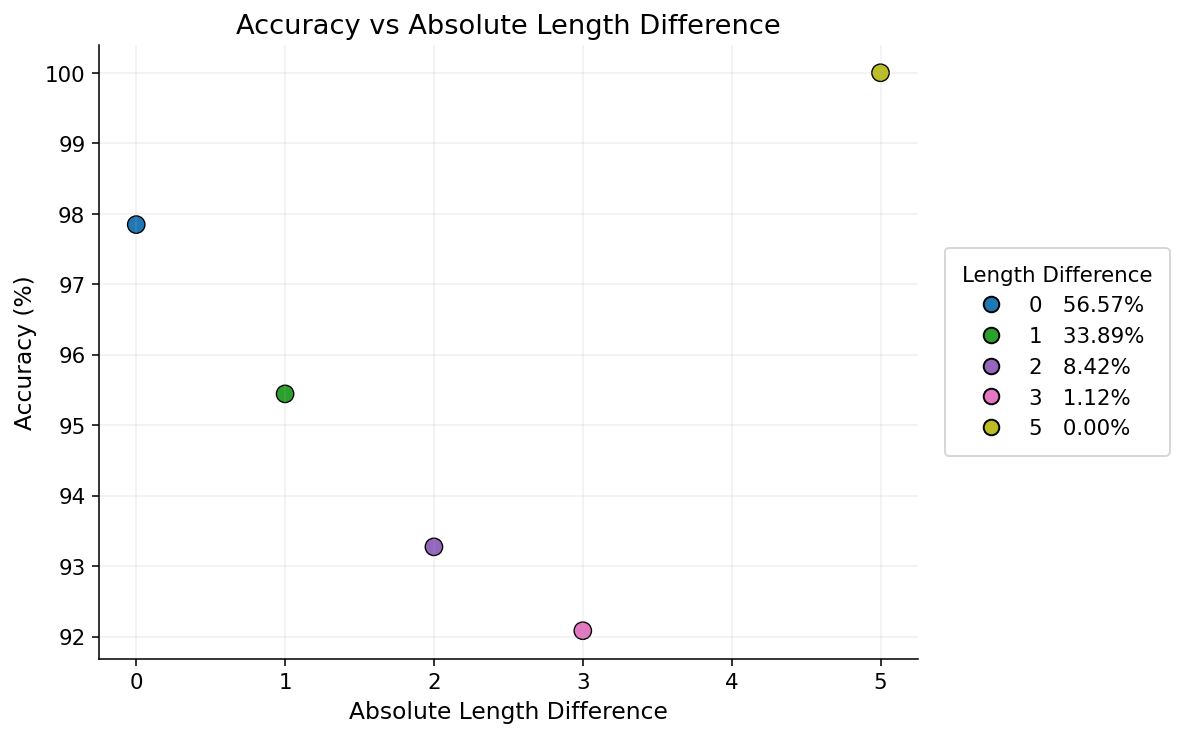

In [25]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.lines import Line2D


ERROR_SUMMARY_PATH = Path("total_5f_error_type_summary.txt")
AVG_LEN_PATH = Path("total_5f_accuracy_by_avg_string_length.txt")
ABS_DIFF_PATH = Path("total_5f_accuracy_by_abs_length_difference.txt")


plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.18
})


def read_pipe_table(path):
    df = pd.read_csv(path, sep="|", engine="python")
    df.columns = [c.strip() for c in df.columns]

    for c in df.columns:
        if df[c].dtype == object:
            df[c] = df[c].astype(str).str.strip()

    return df


def clean_name(x):
    x = x.replace("_", " ").title()
    x = x.replace("Ascii", "ASCII")
    return x


def generate_colors(n):
    cmap = plt.get_cmap("tab20")
    return [cmap(i / max(n, 1)) for i in range(n)]


def build_legend(ax, labels, values, colors, title):
    handles = []

    max_label = max(len(l) for l in labels)

    for lab, val, col in zip(labels, values, colors):
        text = f"{lab:<{max_label}}   {val}"
        handles.append(
            Line2D(
                [0], [0],
                marker="o",
                color="w",
                markerfacecolor=col,
                markeredgecolor="black",
                markersize=8,
                label=text
            )
        )

    ax.legend(
        handles=handles,
        title=title,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
        borderpad=0.8
    )


def _boxes_overlap(a, b, pad=2.0):
    return not (
        a.x1 + pad < b.x0 or
        a.x0 - pad > b.x1 or
        a.y1 + pad < b.y0 or
        a.y0 - pad > b.y1
    )


def _point_in_box(px, py, box, pad=4.0):
    return (
        (box.x0 - pad) <= px <= (box.x1 + pad) and
        (box.y0 - pad) <= py <= (box.y1 + pad)
    )


def add_nonoverlapping_labels(ax, x, y, labels, fontsize=10):
    fig = ax.figure
    renderer = fig.canvas.get_renderer()

    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()

    x_span = x_max - x_min
    y_span = y_max - y_min

    placed_boxes = []
    texts = []

    offsets = [
        (10, 8), (10, -10), (-10, 8), (-10, -10),
        (16, 0), (-16, 0), (0, 14), (0, -14),
        (20, 12), (20, -12), (-20, 12), (-20, -12),
        (28, 0), (-28, 0), (0, 22), (0, -22),
        (34, 14), (34, -14), (-34, 14), (-34, -14),
    ]

    order = np.argsort(-(np.asarray(x) + np.asarray(y)))

    for idx in order:
        xi = x[idx]
        yi = y[idx]
        label = labels[idx]

        point_disp = ax.transData.transform((xi, yi))
        best_text = None
        best_box = None

        for dx, dy in offsets:
            tx = xi + (dx / 72.0) * (x_span / 6.5)
            ty = yi + (dy / 72.0) * (y_span / 4.5)

            tx = min(max(tx, x_min + 0.02 * x_span), x_max - 0.02 * x_span)
            ty = min(max(ty, y_min + 0.03 * y_span), y_max - 0.03 * y_span)

            t = ax.text(
                tx,
                ty,
                label,
                fontsize=fontsize,
                ha="center",
                va="center",
                zorder=5,
                bbox=dict(boxstyle="round,pad=0.22", fc="white", ec="none", alpha=0.88)
            )

            fig.canvas.draw()
            box = t.get_window_extent(renderer=renderer)

            overlaps_existing = any(_boxes_overlap(box, old_box, pad=2.0) for old_box in placed_boxes)
            covers_point = any(
                _point_in_box(*ax.transData.transform((xj, yj)), box, pad=5.0)
                for xj, yj in zip(x, y)
            )

            if not overlaps_existing and not covers_point:
                best_text = t
                best_box = box
                break

            t.remove()

        if best_text is None:
            t = ax.text(
                xi + 0.02 * x_span,
                yi + 0.02 * y_span,
                label,
                fontsize=fontsize,
                ha="left",
                va="bottom",
                zorder=5,
                bbox=dict(boxstyle="round,pad=0.22", fc="white", ec="none", alpha=0.88)
            )
            fig.canvas.draw()
            box = t.get_window_extent(renderer=renderer)
            best_text = t
            best_box = box

        placed_boxes.append(best_box)
        texts.append(best_text)

    return texts


# =====================================================
# ERROR TYPE SCATTER
# =====================================================

def get_error_type_plot_df(df):
    plot_df = df.dropna(subset=[
        "frequency_pct",
        "model_missed_pct",
        "raw_errors",
        "avg_fraudulent_name_length",
        "avg_real_name_length",
        "avg_length_distance",
    ])

    top_raw = plot_df.sort_values("raw_errors", ascending=False).head(5)

    top_miss = (
        plot_df
        .sort_values("model_missed_pct", ascending=False)
        .loc[~plot_df["classification_type"].isin(top_raw["classification_type"])]
        .head(3)
    )

    plot_df = (
        pd.concat([top_raw, top_miss])
        .drop_duplicates(subset=["classification_type"])
        .reset_index(drop=True)
        .copy()
    )

    plot_df["Mechanism"] = plot_df["classification_type"].map(clean_name)
    return plot_df


def plot_error_type_scatter(df):
    plot_df = get_error_type_plot_df(df)
    colors = generate_colors(len(plot_df))

    fig, ax = plt.subplots(figsize=(9.2, 5.8))

    x = plot_df["frequency_pct"].to_numpy()
    y = plot_df["model_missed_pct"].to_numpy()

    ax.scatter(
        x,
        y,
        s=95,
        c=colors,
        edgecolor="black",
        linewidth=0.7,
        zorder=3
    )

    x_pad = max(1.0, 0.08 * (x.max() - x.min() if len(x) > 1 else 1.0))
    y_pad = max(1.0, 0.12 * (y.max() - y.min() if len(y) > 1 else 1.0))
    ax.set_xlim(max(0, x.min() - x_pad), x.max() + x_pad)
    ax.set_ylim(max(0, y.min() - y_pad), y.max() + y_pad)

    add_nonoverlapping_labels(
        ax=ax,
        x=x,
        y=y,
        labels=plot_df["Mechanism"].tolist(),
        fontsize=9.5
    )

    ax.set_xlabel("Frequency Among Positive Examples (%)")
    ax.set_ylabel("Miss Rate Within Error Type (%)")
    ax.set_title("Most Impactful Error Types")
    ax.grid(True, zorder=0)

    plt.tight_layout()
    plt.show()

def plot_error_type_table(df):
    base_plot_df = get_error_type_plot_df(df).reset_index(drop=True)
    base_colors = generate_colors(len(base_plot_df))
    color_map = dict(zip(base_plot_df["classification_type"], base_colors))

    plot_df = base_plot_df.sort_values(
        ["model_missed_pct", "raw_errors"],
        ascending=[False, False]
    ).reset_index(drop=True)

    colors = [color_map[k] for k in plot_df["classification_type"]]

    display_df = plot_df.copy()
    display_df["Number of Errors"] = display_df["raw_errors"].astype(int)
    display_df["Average Fraudulent Name Length"] = display_df["avg_fraudulent_name_length"].map(lambda v: f"{v:.2f}")
    display_df["Average Real Name Length"] = display_df["avg_real_name_length"].map(lambda v: f"{v:.2f}")
    display_df["Average Length Difference"] = display_df["avg_length_distance"].map(lambda v: f"{v:.2f}")

    columns = [
        "",
        "Mechanism",
        "Errors",
        "Avg Fraudulent\nLength",
        "Avg Real\nLength",
        "Avg Length\nDifference",
    ]

    cell_text = [
        [
            "",
            row["Mechanism"],
            f"{row['Number of Errors']}",
            row["Average Fraudulent Name Length"],
            row["Average Real Name Length"],
            row["Average Length Difference"],
        ]
        for _, row in display_df.iterrows()
    ]

    fig, ax = plt.subplots(figsize=(11.4, 3.8))
    ax.axis("off")
    ax.set_title("Summary Statistics for Most Impactful Error Types", pad=14)

    table = ax.table(
        cellText=cell_text,
        colLabels=columns,
        cellLoc="center",
        colLoc="center",
        bbox=[0.03, 0.02, 0.94, 0.88]
    )

    table.auto_set_font_size(False)
    table.set_fontsize(8.5)
    table.scale(1, 1.45)

    col_widths = {
        0: 0.045,
        1: 0.17,
        2: 0.09,
        3: 0.19,
        4: 0.16,
        5: 0.18,
    }

    n_rows = len(cell_text) + 1
    n_cols = len(columns)

    for c in range(n_cols):
        for r in range(n_rows):
            cell = table[(r, c)]
            cell.set_width(col_widths[c])
            cell.set_edgecolor("#bfbfbf")
            cell.set_linewidth(0.8)

            if r == 0:
                cell.set_text_props(weight="bold", va="center", ha="center")
                cell.get_text().set_fontsize(8.0)
                cell.set_facecolor("#f2f2f2")
                cell.set_height(cell.get_height() * 1.18)

    for i, col in enumerate(colors, start=1):
        dot_cell = table[(i, 0)]
        dot_cell.get_text().set_text("●")
        dot_cell.get_text().set_color(col)
        dot_cell.get_text().set_fontsize(13)
        dot_cell.get_text().set_fontweight("bold")

    plt.tight_layout()
    plt.show()

# =====================================================
# AVG STRING LENGTH
# =====================================================

def plot_avg_length(df):
    df = df.copy()

    df["bucket_mid"] = (
        df["avg_string_length_bucket_start"] +
        df["avg_string_length_bucket_end"]
    ) / 2

    fig, ax = plt.subplots(figsize=(8.6, 5.4))

    x = df["bucket_mid"]
    y = df["accuracy_pct"]

    colors = generate_colors(len(df))

    ax.scatter(
        x,
        y,
        s=80,
        c=colors,
        edgecolor="black",
        linewidth=0.7
    )

    labels = []
    values = []

    for _, row in df.iterrows():
        rng = f"{row['avg_string_length_bucket_start']}–{row['avg_string_length_bucket_end']}"
        labels.append(rng)
        values.append(f"{row['frequency_pct']:.2f}%")

    build_legend(ax, labels, values, colors, "Bucket Frequency")

    ax.set_xlabel("Average String Length")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Accuracy vs Average String Length")

    ax.grid(True)

    plt.tight_layout()
    plt.show()


# =====================================================
# ABSOLUTE LENGTH DIFFERENCE (NO BUCKETS)
# =====================================================

def plot_length_diff(df):
    fig, ax = plt.subplots(figsize=(8.6, 5.4))

    x = df["abs_length_difference"]
    y = df["accuracy_pct"]

    colors = generate_colors(len(df))

    ax.scatter(
        x,
        y,
        s=80,
        c=colors,
        edgecolor="black",
        linewidth=0.7
    )

    labels = []
    values = []

    for _, row in df.iterrows():
        labels.append(str(int(row["abs_length_difference"])))
        values.append(f"{row['frequency_pct']:.2f}%")

    build_legend(ax, labels, values, colors, "Length Difference")

    ax.set_xlabel("Absolute Length Difference")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Accuracy vs Absolute Length Difference")

    ax.grid(True)

    plt.tight_layout()
    plt.show()


# =====================================================
# LOAD FILES
# =====================================================

error_df = read_pipe_table(ERROR_SUMMARY_PATH)
avg_len_df = read_pipe_table(AVG_LEN_PATH)
abs_diff_df = read_pipe_table(ABS_DIFF_PATH)


for c in [
    "frequency_pct",
    "model_missed_pct",
    "raw_errors",
    "avg_fraudulent_name_length",
    "avg_real_name_length",
    "avg_length_distance",
]:
    error_df[c] = pd.to_numeric(error_df[c], errors="coerce")

for c in [
    "avg_string_length_bucket_start",
    "avg_string_length_bucket_end",
    "accuracy_pct",
    "frequency_pct"
]:
    avg_len_df[c] = pd.to_numeric(avg_len_df[c], errors="coerce")

for c in [
    "abs_length_difference",
    "accuracy_pct",
    "frequency_pct"
]:
    abs_diff_df[c] = pd.to_numeric(abs_diff_df[c], errors="coerce")


print("Error summary:")
display(error_df)

print("\nAverage string length buckets:")
display(avg_len_df)

print("\nAbsolute length difference:")
display(abs_diff_df)


plot_error_type_scatter(error_df)
plot_error_type_table(error_df)
plot_avg_length(avg_len_df)
plot_length_diff(abs_diff_df)
